# 1. 编译过程

编译器:程序员和计算机之间的翻译官。
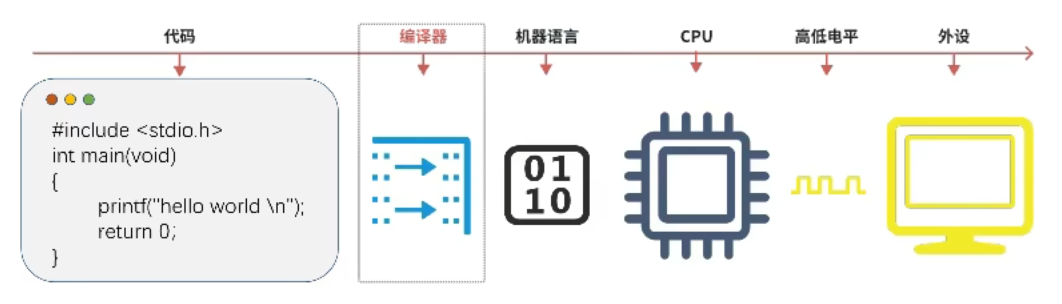

感性认识一下：使用gcc -o bin1 1.c -v

不仅可以看到gcc版本信息，还可以把gcc编译.c文件的过程展示出来。
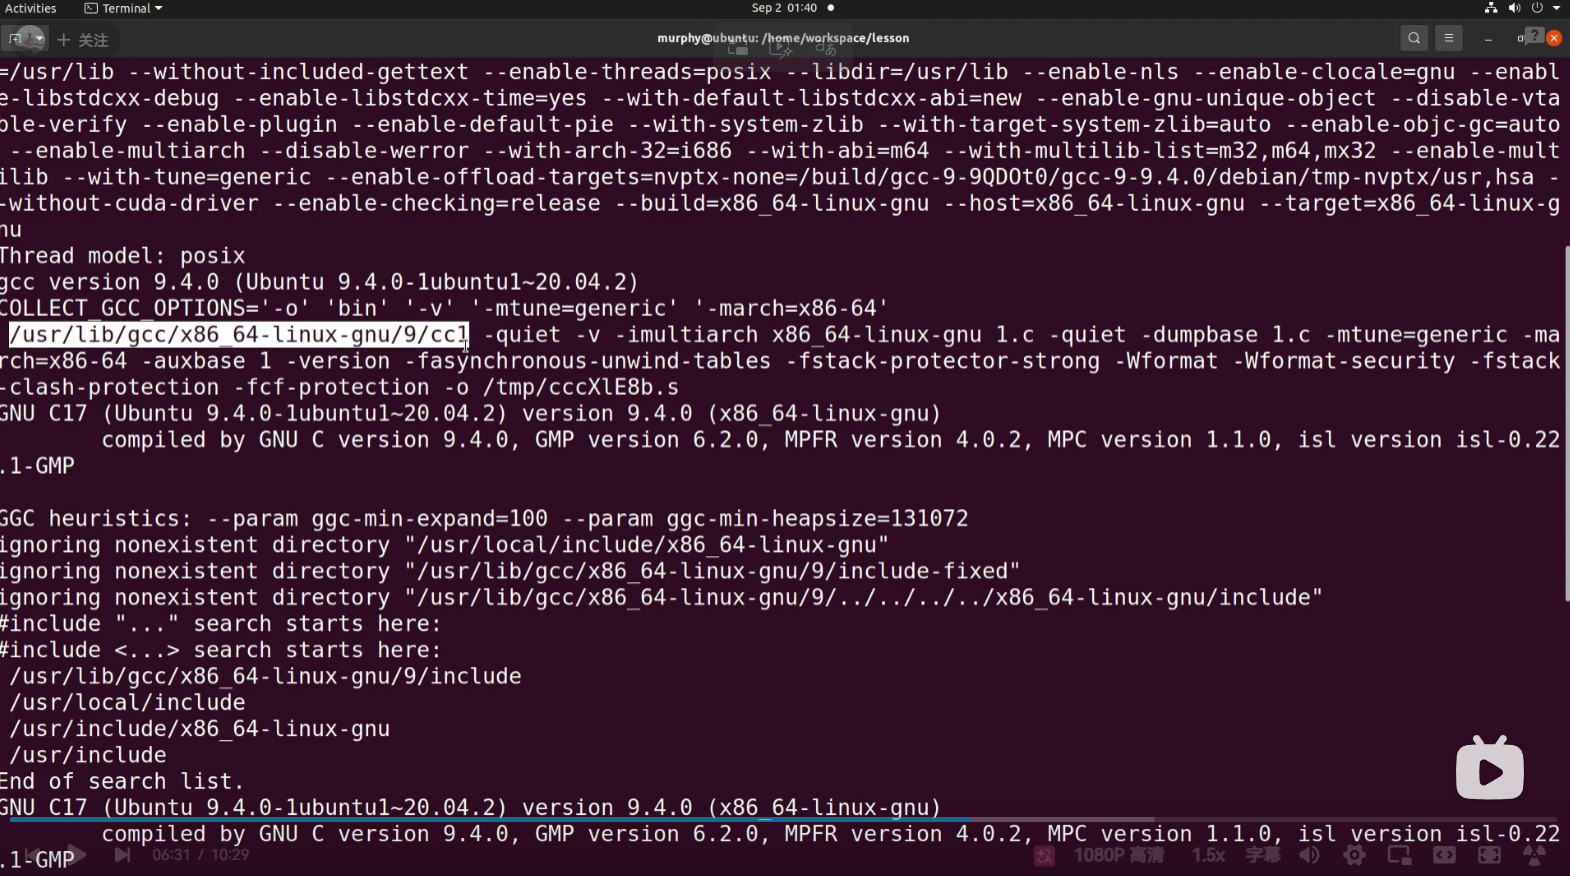

## 1.1 编译过程之预编译
命令行：gcc -o 1.i 1.c -E

*.i是 GCC 约定的预处理后 C 文件的标准扩展名，-E告诉 GCC只运行 C 预处理器，预处理完成后立即终止，不执行后续任何阶段

C 预处理器是一个文本替换工具，它会处理所有以#开头的预处理指令，主要完成以下 6 项工作：
- 宏定义展开：将#define定义的宏替换为其实际值，包括带参数的宏
- 头文件包含：将#include <stdio.h>或#include "myheader.h"指定的头文件内容完整插入到源代码中
- 条件编译处理：解析#ifdef、#ifndef、#if、#else、#endif等指令，只保留符合条件的代码段
- 删除所有注释：移除//单行注释和/* */多行注释
- 添加行号标记：插入#line指令，用于后续编译阶段的错误提示能准确定位到原始代码行
- 处理特殊指令：执行#error（终止编译并报错）、#warning（输出警告）、#pragma（编译器特定指令）等
- 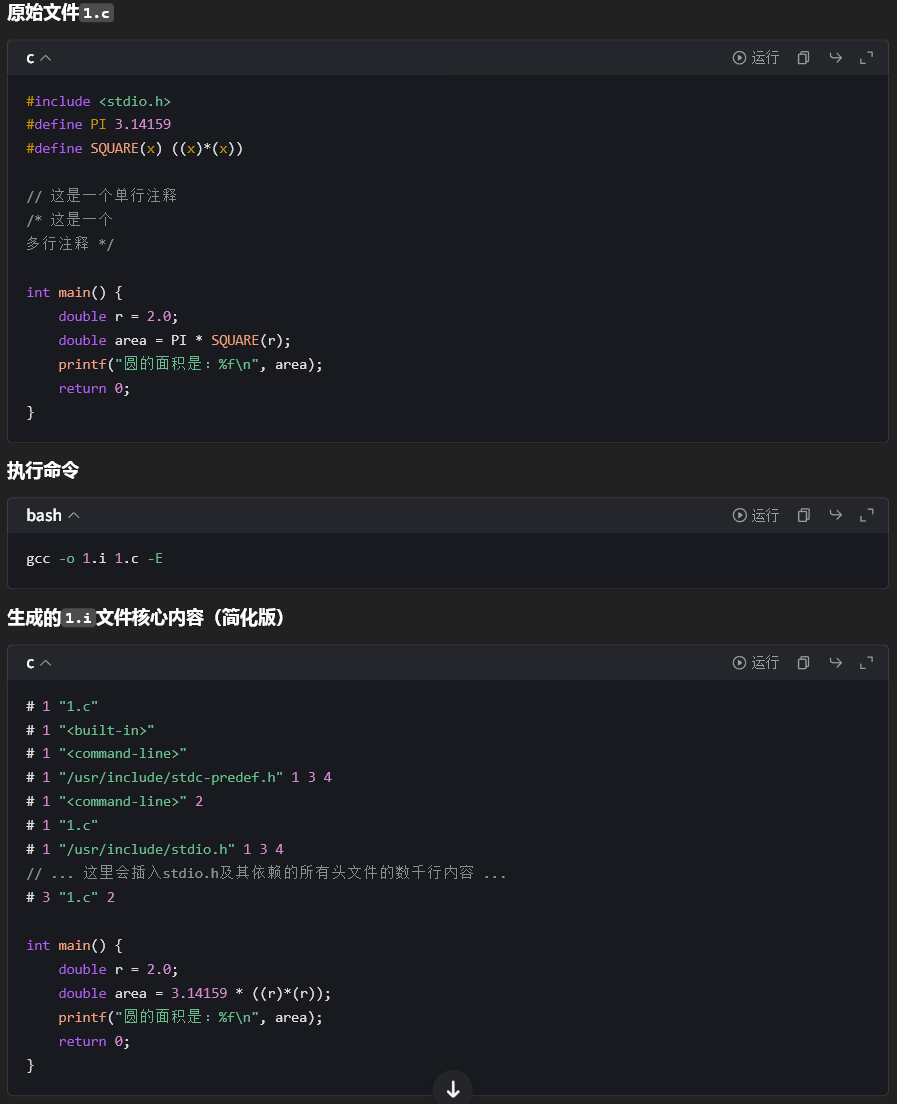

## 1.2 编译过程之编译「生成汇编代码」
命令行：gcc -o 1.s 1.i -S

*.s是 GCC 约定的汇编语言源文件的标准扩展名，-S告诉 GCC 执行完编译阶段后立即终止，不调用汇编器和链接器
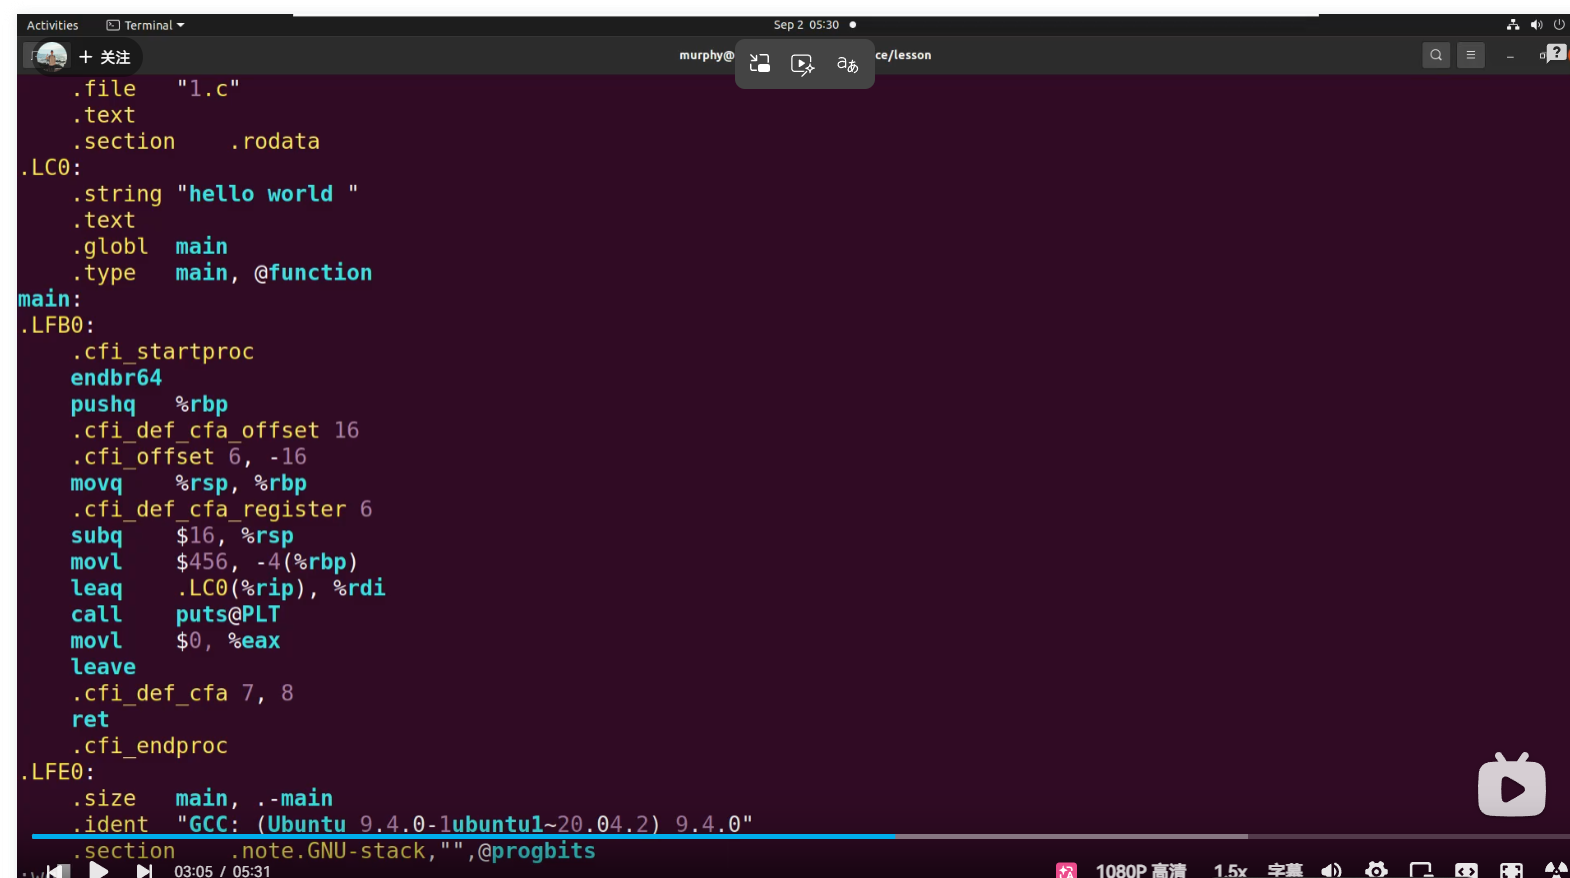

## 1.3 编译过程之汇编「生成目标文件」
gcc -o 1.o 1.c -c（小写 c）：这是 GCC 编译流程的第三阶段专用命令，它会自动完成预处理 + 编译 + 汇编三个阶段，直接生成二进制目标文件1.o，不执行最后的链接步骤。

gcc -o 1.o 1.s -c：这个命令是汇编阶段的标准分步写法，也是学习 GCC 编译四阶段的关键一步。它只执行纯汇编阶段，将上一阶段生成的汇编语言文件1.s直接转换成二进制目标文件1.o，不执行预处理、编译和链接。打包成标准的 ELF 格式目标文件1.o

# 2. 预处理
预处理在工程上有很多的用处，特别是在代码管理、调试上有很多编程技巧可以用。

## 2.1 条件编译
- 调试版本和release版本(调试信息的脱敏、性能的影响:code大小、运行效率有要求)

In [ ]:
#include <stdio.h>

int password = 0x37847110;

int main(void) {
    printf("normal program output\n");    // 两个版本都生效
    return 0;
}

要求在release版本中去掉调试信息，提升性能，减少代码体积。可以使用条件编译来实现：

In [ ]:
#include <stdio.h>

#ifdef DEBUG
// 自动包含文件名、行号，方便定位问题
///可变参数的函数式宏
#define DEBUG_LOG(fmt, ...) \
    printf("[DEBUG] %s:%d: " fmt "\n", __FILE__, __LINE__, ##__VA_ARGS__)
#else
// Release版本完全消除日志开销
//((void)0) 是一个无副作用的表达式语句，语法上完全合法，不会产生任何机器码。编译器会把它完全优化掉，相当于什么都没写。
#define DEBUG_LOG(fmt, ...) ((void)0)
#endif

int password = 0x37847110;

int main(void) {
    DEBUG_LOG("password is %x", password); // 仅Debug版生效
    printf("normal program output\n");    // 两个版本都生效
    return 0;
}

可以通过编译选项传递给编译器

- Debug版本：定义DEBUG宏
  
gcc -o debug test.c -D DEBUG

这个-D DEBUG其实默认定义了#define DEBUG 1

- Release版本：不定义DEBUG宏
  
gcc -o release test.c

- Feature 宏（功能宏）
  
Feature 宏是用来控制软件中可选功能模块是否被编译进最终产品的预处理器宏。它的核心思想是：把软件拆分成一个个独立的 "功能特性（Feature）"，每个特性对应一个宏开关。通过在编译时打开或关闭这些开关，就能灵活组合出不同功能的产品版本，而无需修改任何业务代码。

- 在工业级嵌入式项目中，每个驱动都是一个独立的模块，有自己单独的.c 源文件和.h 头文件。这是软件工程最基本的模块化原则。
```
project/
├── include/          # 头文件目录
│   ├── config.h      # 所有Feature宏的集中定义
│   ├── tp.h          # 触摸屏驱动头文件
│   ├── lcd.h         # LCD驱动头文件
│   └── keyboard.h    # 键盘驱动头文件
├── src/              # 源文件目录
│   ├── drivers/      # 驱动目录，每个驱动一个子目录或文件
│   │   ├── tp.c      # 触摸屏驱动实现
│   │   ├── lcd.c     # LCD驱动实现
│   │   └── keyboard.c# 键盘驱动实现
│   └── main.c        # 主函数
└── Makefile          # 编译脚本
```

In [ ]:
//头文件只包含函数原型、宏定义、数据结构声明，不包含任何实现代码。同样要用 Feature 宏包裹：

#ifndef TP_H
#define TP_H

#include "config.h"

#ifdef TOUCH_PANEL_DRIVER
// 触摸屏驱动初始化函数声明
void tp_driver_init(void);
// 触摸屏读取坐标函数声明
void tp_get_point(int *x, int *y);
#endif

#endif // TP_H

In [ ]:
//硬件操作逻辑都写在对应的.c 文件里
#include "tp.h"
#include "stm32f4xx_gpio.h"  // 芯片寄存器头文件
#include "stm32f4xx_i2c.h"   // 外设总线头文件

#ifdef TOUCH_PANEL_DRIVER
// 触摸屏芯片I2C地址
// 触摸屏寄存器地址
void tp_driver_init(void) {
    // 1. 初始化GPIO引脚（复位引脚、中断引脚）
    // 2. 复位触摸屏芯片
    // 3. 初始化I2C总线
    // 4. 配置触摸屏芯片寄存器
    printf("TP driver init success\n");
}
void tp_get_point(int *x, int *y) {
    uint8_t xh, xl, yh, yl;
    xh = i2c_read_reg(TP_I2C_ADDR, TP_REG_X_H);
    xl = i2c_read_reg(TP_I2C_ADDR, TP_REG_X_L);
    yh = i2c_read_reg(TP_I2C_ADDR, TP_REG_Y_H);
    yl = i2c_read_reg(TP_I2C_ADDR, TP_REG_Y_L);
    *x = ((xh & 0x0F) << 8) | xl;
    *y = ((yh & 0x0F) << 8) | yl;
}
#endif // TOUCH_PANEL_DRIVER

In [ ]:
//主函数只需要包含对应的头文件，然后调用驱动接口即可
#include <stdio.h>
#include "config.h"
#include "tp.h"
#include "lcd.h"
#include "keyboard.h"

int main(void) {
    // 系统时钟初始化
    system_clock_init();
    
    // 串口初始化（用于printf输出）
    uart_init(115200);
    
    printf("System booting...\n");
    
#ifdef TOUCH_PANEL_DRIVER
    tp_driver_init();
#endif

#ifdef LCD_DRIVER
    lcd_driver_init();
#endif

#ifdef KEYBOARD_DRIVER
    keyboard_driver_init();
#endif

    printf("System boot complete\n");
    
    // 主循环
    while (1) {
#ifdef TOUCH_PANEL_DRIVER
        int x, y;
        tp_get_point(&x, &y);
        printf("Touch point: (%d, %d)\n", x, y);
#endif
        delay_ms(100);
    }
    
    return 0;
}

- #warning 与 #error 预处理器指令在编译阶段检查配置错误
  
所有的#error和#warning检查应该集中放在config.h文件的开头，这样所有的配置错误都会在编译一开始就被发现。

In [ ]:
// config.h
#ifndef CONFIG_H
#define CONFIG_H

// 强制检查
#ifndef CPU_ARCH
#error "必须定义CPU_ARCH宏"
#endif

// 依赖检查
#ifdef LCD_DRIVER
#ifndef SPI_DRIVER
#error "LCD驱动依赖SPI驱动"
#endif
#endif

// 提醒检查
#ifndef DEBUG
#warning "未定义DEBUG宏，默认生成Release版本"
#endif

#endif // CONFIG_H

## 2.2 宏定义与使用
宏本质上是文本替换工具，预处理器在预处理阶段会将所有宏定义替换为其实际值。宏定义的语法如下： #define 宏名 替换文本
- 当替换成运算表达式的时候，可以添加一个（），来保证运算的正确性

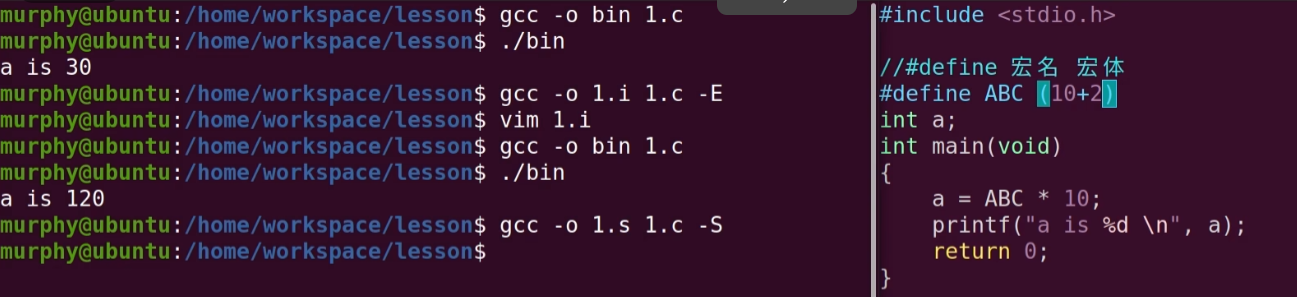
- 宏嵌套，实际的展开过程，先处理外层宏，再处理内层宏

## 2.3 宏函数

- 同理有优先级问题
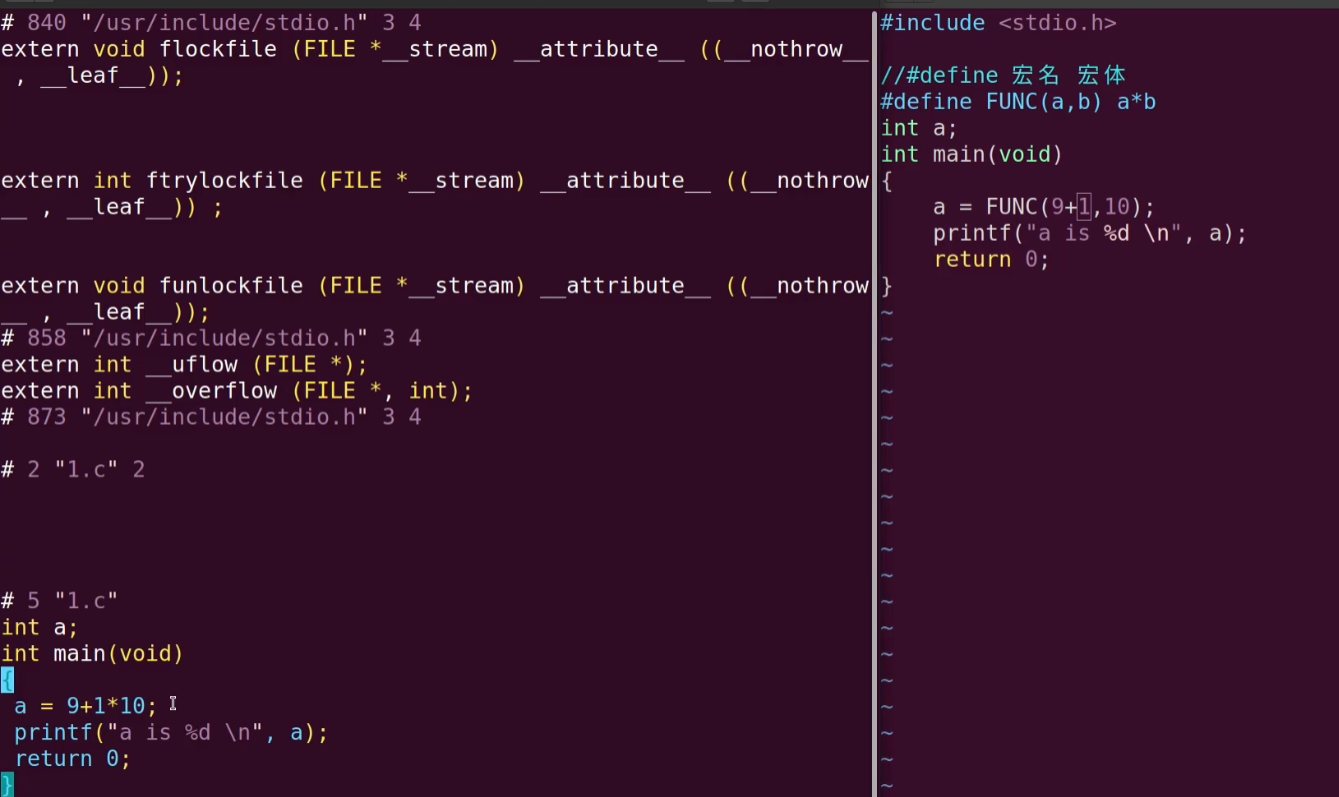

## 2.4 调试LOG宏
```c
"# 字符化 :将宏参数x原封不动地转换为双引号包裹的字符串字面量,#后面的参数不会被进一步展开，会保留原始的文本内容"

"## 连接符: 将##左右两边的标记拼接成一个新的 C 语言标识符（变量名、函数名等）,##两边的参数会被展开，然后再进行拼接"

"__FUNCTION__预定义宏，表示当前函数的名字"

"__LINE__预定义宏，表示当前行号"

"__FILE__预定义宏，表示当前文件名"
```

In [ ]:
//"# 字符化"
#include <stdio.h>
#define LOG_INFO(x) printf("x is %d\n", (x));

int main(void){
    int a = 10;
    LOG_INFO(a);
    return 0;
}

运行结果是 x is 10
但是我们想要x会随着参数的变化而变化，应该怎么做呢？

可以用//"# 字符化"

In [ ]:
//"# 字符化"
#include <stdio.h>
#define LOG_INFO(x) printf("%s is %d\n", #x, (x));

int main(void){
    int a = 10;
    LOG_INFO(a);
    return 0;
}

如果要实现一些日期的拼接的话，可以用连接符##来实现

- 宏嵌套，实际的展开过程，先处理外层宏，再处理内层宏

In [ ]:
//## 连接符
#include <stdio.h>
#define LOG_INFO(x) printf("%s is %d\n", #x, (x));
#define DAY_DELARY(x) int day##x
#define DAY(x) day##x
int main(void){
    int a = 10;
    DAY_DELARY(1) = 100;
    DAY_DELARY(21) = 200;
    LOG_INFO(DAY(1));
    LOG_INFO(DAY(21));
    return 0;
}

运行结果是

DAY(1) is 100
DAY(21) is 200

如果要更加具体的分析问题出现在哪里，可以在宏定义中添加__FUNCTION__、__LINE__、__FILE__等预定义宏来输出当前函数名、行号和文件名，帮助定位问题。

In [ ]:
#include <stdio.h>
#define LOG_INFO(x) printf("%s:%s:%d: %s is %d\n",\
    __FILE__,\ 
    __FUNCTION__,\
    __LINE__,\
    #x, (x));
#define DAY_DELARY(x) int day##x
#define DAY(x) day##x
int main(void){
    int a = 10;
    DAY_DELARY(1) = 100;
    DAY_DELARY(21) = 200;
    LOG_INFO(DAY(1));
    LOG_INFO(DAY(21));
    return 0;
}

程序运行结果
1.c:main:13: DAY(1) is 100
1.c:main:14: DAY(21) is 200

- 如果想实现和printf一样的功能，可以使用可变参数宏来实现，语法如下：
```c

... ：可变参数标记，表示可以接受任意数量的额外参数
##__VA_ARGS__: [VA：Variable Arguments可变参数,ARGS：Arguments参数]

```c
#define LOG_INFO(fmt, ...) printf("[INFO] %s:%s:%d: " fmt "\n",\
    __FILE__,\
    __FUNCTION__,\
    __LINE__,\
    ##__VA_ARGS__)
```

In [ ]:
#include <stdio.h>
#define LOG_INFO(fmt, ...) printf("[INFO] %s:%s:%d: " fmt "\n",\
    __FILE__,\ 
    __FUNCTION__,\
    __LINE__,\
    ##__VA_ARGS__)
#define DAY_DELARY(x) int day##x
#define DAY(x) day##x
int main(void){
    int a = 10;
    DAY_DELARY(1) = 100;
    DAY_DELARY(21) = 200;
    LOG_INFO("DAY(1) is %d", DAY(1));
    LOG_INFO("DAY(21) is %d", DAY(21));
    return 0;
}

[INFO] test.c:main:14: DAY1 = 100
[INFO] test.c:main:15: DAY21 = 200